# Week 5 — Deep Learning Application in Data Science

## Objective

This week focuses on applying a neural network to the Adult Income classification problem.

The objective is to predict whether an individual earns more than $50K per year using demographic, educational, employment, and financial characteristics.

The project will cover data preparation, feature preprocessing, neural network architecture design, model training, validation, evaluation, and analysis of challenges such as overfitting and class imbalance.

The performance of the neural network will also be compared with the traditional machine-learning results obtained in Week 4.

## Project Workflow

The deep learning workflow will follow these stages:

1. Load and prepare the dataset
2. Define the classification target
3. Prepare numerical and categorical features
4. Apply preprocessing
5. Split the data into training, validation, and test sets
6. Design the neural network architecture
7. Train the model
8. Monitor training and validation performance
9. Evaluate the model using multiple metrics
10. Analyze overfitting and class imbalance
11. Improve the model if necessary
12. Compare the neural network with the Week 4 baseline
13. Draw conclusions about the effectiveness of the deep learning approach

In [1]:
import sys

print(sys.executable)


c:\Users\bharg\OneDrive\Apps\adult-income-data-cleaning\venv-dl\Scripts\python.exe


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
Available GPUs: []


## 1. Dataset Loading

The cleaned Adult Income dataset prepared in the previous weeks is used for the deep learning experiment.

The target variable is `income`, where the objective is to classify individuals into two income groups: `<=50K` and `>50K`.

In [4]:
import pandas as pd
import numpy as np

# Load the cleaned dataset
df = pd.read_csv("../data/processed/adult_cleaned.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (32537, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Dataset Overview

The cleaned Adult Income dataset contains demographic, educational, employment, and financial attributes for individuals. The `income` column is used as the target variable.

The deep learning model will learn patterns from the remaining features and predict whether an individual's income is `<=50K` or `>50K`.

## 2. Target Variable Analysis

The `income` column is the target variable for the classification problem.

The model will predict two classes:

- `<=50K`
- `>50K`

Before training the neural network, the distribution of these classes is examined because an imbalanced target can affect model performance, particularly recall for the minority class.

In [5]:
# Check the target distribution
target_counts = df["income"].value_counts()
target_percent = df["income"].value_counts(normalize=True) * 100

print("Income class counts:")
print(target_counts)

print("\nIncome class percentages:")
print(target_percent.round(2))

Income class counts:
income
<=50K    24698
>50K      7839
Name: count, dtype: int64

Income class percentages:
income
<=50K    75.91
>50K     24.09
Name: proportion, dtype: float64


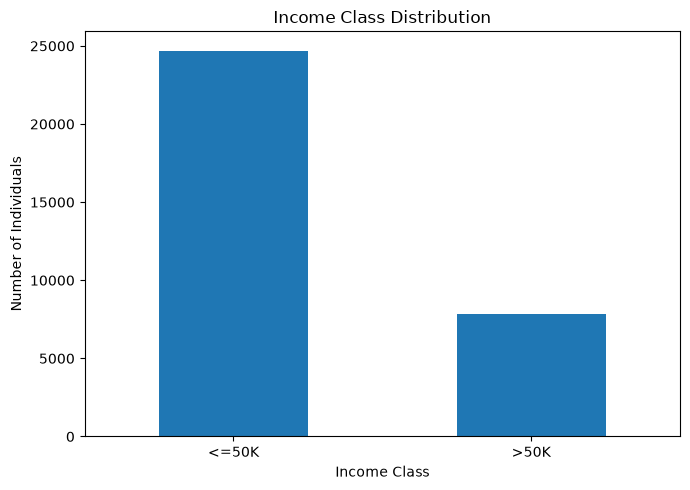

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

target_counts.plot(kind="bar")

plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/week5_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The target distribution shows that the `<=50K` class contains substantially more observations than the `>50K` class. This indicates class imbalance in the dataset.

Because the neural network should not simply favor the majority class, accuracy alone will not be sufficient for evaluating the model. Precision, recall, F1-score, ROC-AUC, and the confusion matrix will also be considered.

The class imbalance will be taken into account during model training and evaluation.

In [7]:
plt.savefig("../screenshots/week5_target_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## 3. Feature and Target Preparation

The `income` column is separated from the input features because it represents the prediction target.

For binary classification, the target is encoded as:

- `<=50K` → 0
- `>50K` → 1

The remaining columns are used as input features for the neural network.

In [8]:
# Separate features and target
X = df.drop("income", axis=1)
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

print("\nMissing target values:", y.isna().sum())

Feature shape: (32537, 14)
Target shape: (32537,)

Target values:
income
0    24698
1     7839
Name: count, dtype: int64

Missing target values: 0


In [9]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Number of numerical features: 6
Number of categorical features: 8


C:\Users\bharg\AppData\Local\Temp\ipykernel_3340\2425038504.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


## 4. Train, Validation, and Test Split

The dataset is divided into training, validation, and test sets.

A 70/15/15 split is used. The training set is used to learn the neural-network parameters, while the validation set is used to monitor performance during training and help identify overfitting. The test set is kept separate until the final evaluation.

Stratified splitting is used to preserve the proportion of the two income classes in each subset.

In [10]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide the temporary set equally
# This gives 15% validation and 15% test overall
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nClass distribution:")
print("Training:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (22775, 14) (22775,)
Validation set: (4881, 14) (4881,)
Test set: (4881, 14) (4881,)

Class distribution:
Training:
income
0    0.759
1    0.241
Name: proportion, dtype: float64

Validation:
income
0    0.759
1    0.241
Name: proportion, dtype: float64

Test:
income
0    0.759
1    0.241
Name: proportion, dtype: float64


## 5. Feature Preprocessing

Neural networks work with numerical input values, so the categorical variables must be converted into numerical representations.

One-hot encoding is applied to the categorical features. Numerical features are standardized using `StandardScaler`, which gives them a comparable scale and helps the neural network train more effectively.

The preprocessing transformer is fitted only on the training data to prevent information from the validation and test sets from leaking into the training process.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (22775, 108)
Processed validation shape: (4881, 108)
Processed test shape: (4881, 108)


In [12]:
print("Data type:", X_train_processed.dtype)
print("Training samples:", X_train_processed.shape[0])
print("Input features after encoding:", X_train_processed.shape[1])

print("\nAny NaN values:")
print("Train:", np.isnan(X_train_processed).sum())
print("Validation:", np.isnan(X_val_processed).sum())
print("Test:", np.isnan(X_test_processed).sum())

Data type: float64
Training samples: 22775
Input features after encoding: 108

Any NaN values:
Train: 0
Validation: 0
Test: 0


### Interpretation

The categorical variables are expanded into binary one-hot encoded columns, increasing the number of input features available to the neural network.

Numerical variables are standardized so that features with larger numerical ranges do not dominate the learning process.

The preprocessing is fitted only on the training data and then applied to the validation and test sets. This prevents data leakage and ensures that the final test evaluation represents unseen data.

## 6. Neural Network Architecture

A fully connected feed-forward neural network is designed for the binary income classification problem.

The network contains an input layer followed by two hidden layers with 64 and 32 neurons. ReLU activation is used in the hidden layers to introduce non-linearity. Dropout layers are included to reduce the risk of overfitting.

The final layer contains a single neuron with sigmoid activation. This produces a probability representing the likelihood that an individual belongs to the `>50K` income class.

### Architecture

Input Features
→ Dense(64, ReLU)
→ Dropout(0.30)
→ Dense(32, ReLU)
→ Dropout(0.20)
→ Dense(1, Sigmoid)

The model is intentionally kept relatively compact because the Adult Income dataset is tabular rather than image- or sequence-based. A smaller network also reduces unnecessary computational cost while still providing enough capacity to learn non-linear relationships.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Number of input features after one-hot encoding
input_dim = X_train_processed.shape[1]

# Build the neural network
model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    
    layers.Dense(1, activation="sigmoid")
])

# Display architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


## 7. Handling Class Imbalance

The target variable is imbalanced, with substantially more observations in the `<=50K` class than in the `>50K` class.

To reduce the tendency of the neural network to favor the majority class, class weights are calculated from the training data. The minority `>50K` class receives a higher weight during training.

This approach allows the model to pay greater attention to correctly identifying higher-income individuals without artificially changing the original dataset.

In [15]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate balanced class weights using only the training data
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for class_label, weight in class_weights.items():
    print(f"Class {class_label}: {weight:.4f}")

Class weights:
Class 0: 0.6587
Class 1: 2.0754


## 8. Model Training

The neural network is trained for a maximum of 30 epochs with a batch size of 64.

Validation data is monitored during training. Early stopping is used with a patience of 5 epochs so that training stops when validation loss no longer improves.

The best model weights are restored after training. This helps reduce overfitting and ensures that the model used for evaluation corresponds to its best validation performance.

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the neural network
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7731 - loss: 0.4460 - precision: 0.5184 - recall: 0.8196 - val_accuracy: 0.7984 - val_loss: 0.3978 - val_precision: 0.5506 - val_recall: 0.8886
Epoch 2/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7953 - loss: 0.3959 - precision: 0.5484 - recall: 0.8531 - val_accuracy: 0.7916 - val_loss: 0.3948 - val_precision: 0.5403 - val_recall: 0.9073
Epoch 3/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8007 - loss: 0.3856 - precision: 0.5556 - recall: 0.8637 - val_accuracy: 0.8043 - val_loss: 0.3805 - val_precision: 0.5587 - val_recall: 0.8946
Epoch 4/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8055 - loss: 0.3778 - precision: 0.5628 - recall: 0.8637 - val_accuracy: 0.8158 - val_loss: 0.3676 - val_precision: 0.5778 - val_recall: 0.8750
Epoch 5/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8076 - loss: 0.3750 - precision: 0.5657 - recall: 0.8677 - val_accuracy: 0.8193 - val_loss: 0.

## 9. Training and Validation Performance

The training history is visualized using loss and accuracy curves.

The training and validation curves are compared to identify whether the neural network is learning effectively or showing signs of overfitting.

If training performance continues improving while validation performance stops improving or becomes worse, this indicates overfitting. Early stopping was used during training to reduce this risk.


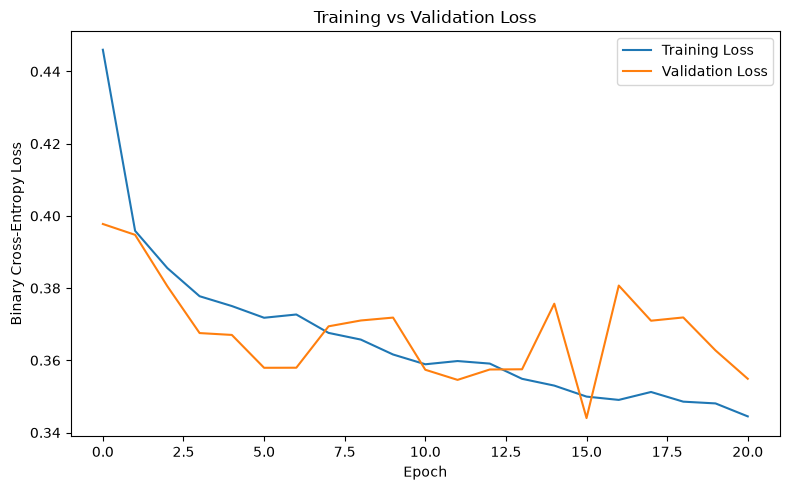

In [17]:
# Extract training history
history_dict = history.history

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

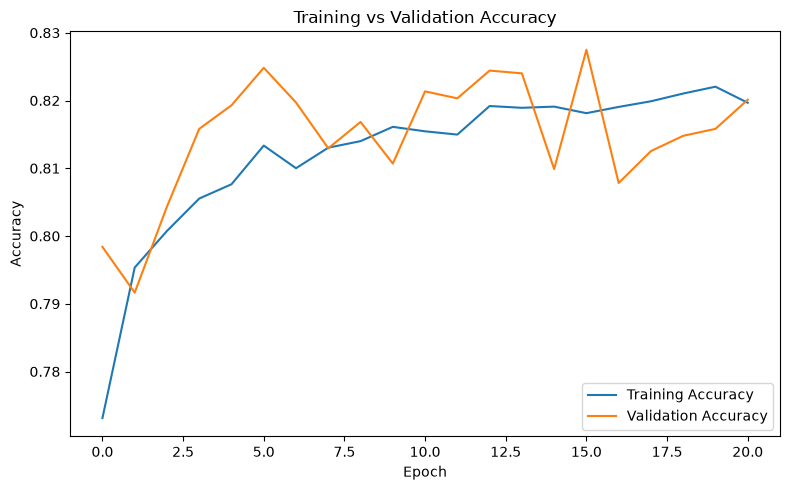

In [18]:
# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The training and validation curves provide an indication of how the neural network generalizes to unseen data during training.

The gap between training and validation performance is examined to identify potential overfitting. The use of dropout and early stopping helps control overfitting by limiting the model's tendency to memorize the training data.

The epoch at which the best validation performance was achieved is also important because the final model uses the restored best weights rather than simply using the weights from the last training epoch.

## 10. Test Set Evaluation

After training, the neural network is evaluated on the held-out test set.

The test set was not used to optimize the model or its parameters. Therefore, its performance provides an estimate of how the trained neural network generalizes to unseen observations.

Multiple evaluation metrics are used because the income classes are imbalanced. Accuracy is reported together with precision, recall, F1-score, and ROC-AUC.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predict probabilities for the positive class (>50K)
y_test_prob = model.predict(X_test_processed, verbose=0).ravel()

# Convert probabilities into class predictions
y_test_pred = (y_test_prob >= 0.5).astype(int)

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Test Set Performance")
print("--------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["<=50K", ">50K"]
    )
)

Test Set Performance
--------------------
Accuracy : 0.8275
Precision: 0.6023
Recall   : 0.8359
F1-Score : 0.7001
ROC-AUC  : 0.9135

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.82      0.88      3705
        >50K       0.60      0.84      0.70      1176

    accuracy                           0.83      4881
   macro avg       0.77      0.83      0.79      4881
weighted avg       0.86      0.83      0.84      4881



## 11. Confusion Matrix

The confusion matrix provides a detailed view of the neural network's classification performance.

It shows the number of correct and incorrect predictions for both income classes. This is particularly useful for understanding how well the model identifies the minority `>50K` class.

Confusion Matrix:
[[3056  649]
 [ 193  983]]


<Figure size 700x500 with 0 Axes>

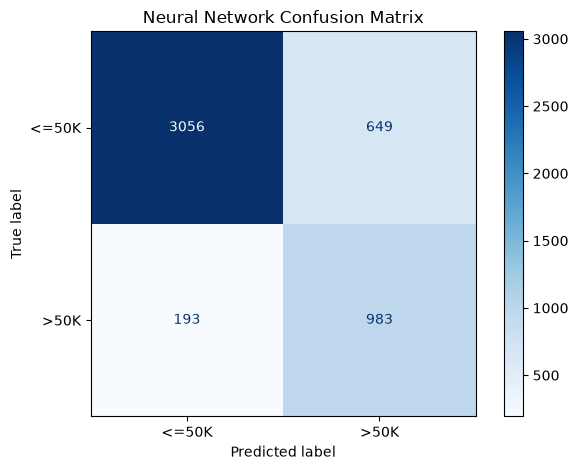

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Neural Network Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The confusion matrix shows the number of correct and incorrect predictions made by the neural network for each income class.

The diagonal values represent correctly classified individuals, while the off-diagonal values represent classification errors.

Particular attention is given to the `>50K` class because it is the minority class. The number of individuals incorrectly classified as `<=50K` indicates the model's false-negative behavior, which is also reflected in the recall score.

## 12. ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the neural network across different classification thresholds.

The ROC curve compares the true-positive rate with the false-positive rate. The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish between the `<=50K` and `>50K` income classes.

A value closer to 1 indicates stronger class-separation ability, while a value around 0.5 indicates performance similar to random classification.

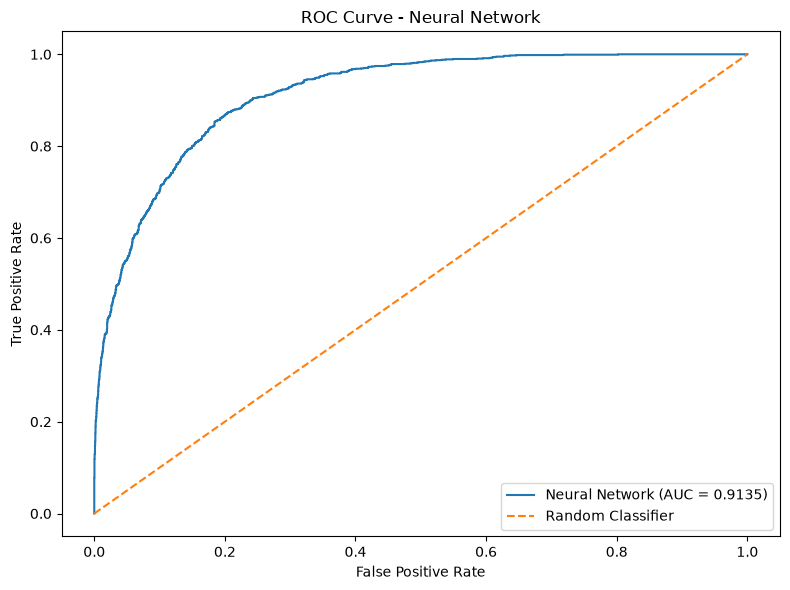

ROC-AUC: 0.9135


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Calculate AUC
roc_auc = roc_auc_score(y_test, y_test_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Neural Network (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Neural Network")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

### Interpretation

The ROC curve illustrates how the true-positive rate changes as the classification threshold is varied.

The ROC-AUC value provides a threshold-independent measure of the neural network's ability to distinguish between the two income classes.

A higher ROC-AUC indicates better separation between the income categories. The ROC-AUC will also be compared with the Week 4 supervised-learning models to determine whether the neural network provides a meaningful improvement.

## 13. Error Analysis

Accuracy and other aggregate metrics do not explain which observations are difficult for the model to classify.

Therefore, prediction errors are analyzed by comparing the characteristics of correctly and incorrectly classified individuals.

The analysis focuses on numerical features such as age, education level, working hours, and capital-related variables. This helps identify patterns that may explain why certain observations are harder for the neural network to classify.

In [22]:
# Create a copy of the test set for error analysis
error_analysis = X_test.copy()

error_analysis["actual_income"] = y_test.values
error_analysis["predicted_income"] = y_test_pred

# Identify correct and incorrect predictions
error_analysis["prediction_correct"] = (
    error_analysis["actual_income"] == error_analysis["predicted_income"]
)

print("Correct predictions:",
      error_analysis["prediction_correct"].sum())

print("Incorrect predictions:",
      (~error_analysis["prediction_correct"]).sum())

print("\nError rate:",
      round(
          (~error_analysis["prediction_correct"]).mean() * 100,
          2
      ),
      "%"
      )

Correct predictions: 4039
Incorrect predictions: 842

Error rate: 17.25 %


In [23]:
# Compare numerical feature averages
numerical_error_comparison = error_analysis.groupby(
    "prediction_correct"
)[numerical_features].mean().T

numerical_error_comparison.columns = [
    "Incorrect Predictions",
    "Correct Predictions"
]

print(numerical_error_comparison.round(2))

                Incorrect Predictions  Correct Predictions
age                             43.72                37.77
fnlwgt                      188662.27            189291.44
education-num                   10.70                 9.91
capital-gain                   350.75              1270.47
capital-loss                   120.70                89.35
hours-per-week                  45.25                39.27


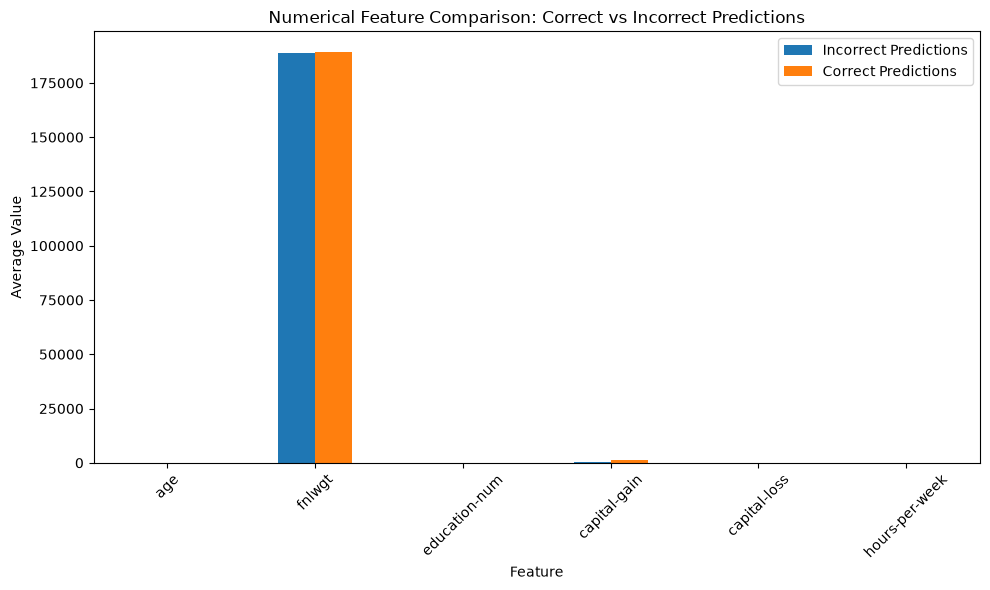

In [24]:
# Plot comparison of numerical feature means
numerical_error_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Numerical Feature Comparison: Correct vs Incorrect Predictions")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_error_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The error analysis compares the average characteristics of correctly and incorrectly classified observations.

Differences in variables such as age, education level, working hours, and capital-related features can indicate which types of observations are more difficult for the neural network to classify.

These differences suggest that some individuals may have characteristics associated with both income categories, making their income class less clearly separable. Such borderline cases are a natural challenge in the Adult Income classification problem.

## 14. Comparison with Week 4 Supervised Learning Models

The neural network is compared with the traditional machine-learning models developed in Week 4.

The comparison focuses on accuracy, precision, recall, F1-score, and ROC-AUC. Since the Adult Income dataset is imbalanced, recall and F1-score for the `>50K` class are particularly important.

The objective is not simply to determine which model has the highest accuracy, but to understand the trade-off between correctly identifying higher-income individuals and maintaining overall predictive performance.

In [25]:
# Week 4 model results
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        0.8579,
        0.8660,
        0.8711,
        0.8178,
        test_accuracy
    ],
    "Precision": [
        0.7419,
        0.7881,
        0.8217,
        0.5808,
        test_precision
    ],
    "Recall": [
        0.6288,
        0.6071,
        0.5938,
        0.8756,
        test_recall
    ],
    "F1-Score": [
        0.6807,
        0.6859,
        0.6894,
        0.6984,
        test_f1
    ],
    "ROC-AUC": [
        0.9147,
        0.9060,
        0.9230,
        0.9233,
        test_auc
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8579,0.7419,0.6288,0.6807,0.9147
1,Decision Tree,0.8660,0.7881,0.6071,0.6859,0.9060
2,Random Forest,0.8711,0.8217,0.5938,0.6894,0.9230
3,Balanced Random Forest,0.8178,0.5808,0.8756,0.6984,0.9233
4,Neural Network,0.8275,0.6023,0.8359,0.7001,0.9135


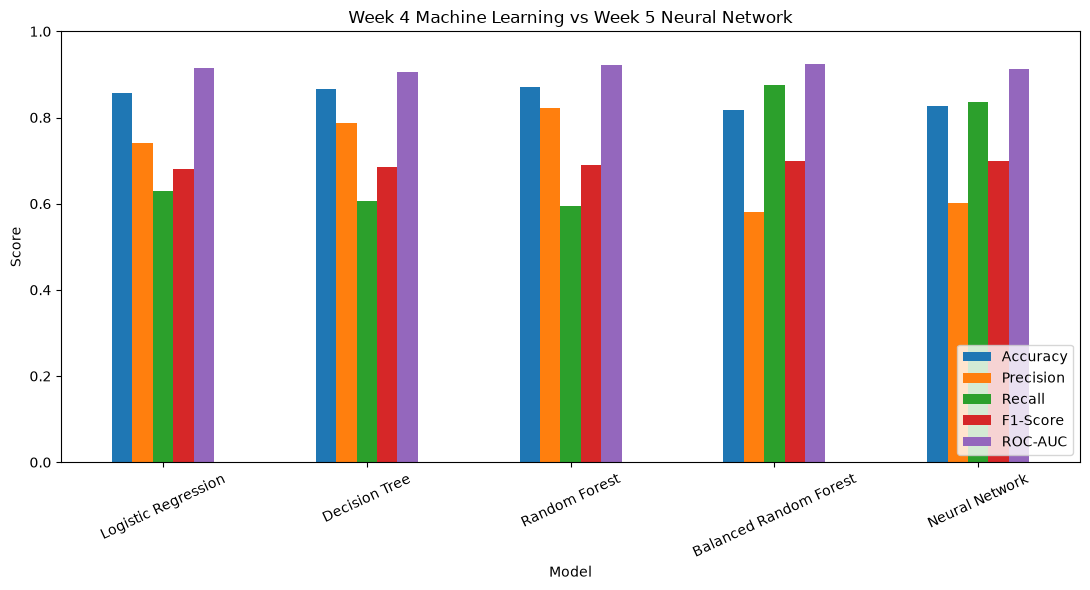

In [26]:
# Plot model comparison
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Week 4 Machine Learning vs Week 5 Neural Network")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The comparison shows that the neural network provides a different performance profile from the traditional machine-learning models.

The neural network achieved strong recall for the `>50K` class, meaning that it successfully identified a large proportion of higher-income individuals. However, this improvement in recall comes with lower precision because more lower-income individuals are classified as belonging to the higher-income class.

The Random Forest from Week 4 achieved higher overall accuracy and ROC-AUC than the neural network, while the neural network achieved substantially higher recall for the minority class than the original Random Forest.

Therefore, the deep-learning model does not automatically outperform the traditional models on every metric. Instead, it provides a useful alternative that prioritizes minority-class detection through class weighting and non-linear representation learning.

## 15. Improved Neural Network Architecture

An improved neural network is developed to determine whether additional model capacity and batch normalization can improve predictive performance.

The improved architecture contains two hidden layers with 128 and 64 neurons. Batch normalization is applied after each hidden layer, followed by dropout to reduce overfitting.

The architecture is:

Input Features
→ Dense(128, ReLU)
→ Batch Normalization
→ Dropout(0.30)
→ Dense(64, ReLU)
→ Batch Normalization
→ Dropout(0.20)
→ Dense(1, Sigmoid)

The original class weights, learning rate, early stopping strategy, and train-validation-test split are retained so that the comparison with the baseline neural network is meaningful.

In [27]:
# Build the improved neural network
improved_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.30),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.20),

    layers.Dense(1, activation="sigmoid")
])

# Compile the improved model
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        13,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,041 (90.00 KB)

 Trainable params: 22,657 (88.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [28]:
# Early stopping for the improved model
improved_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train improved model
improved_history = improved_model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[improved_early_stopping],
    verbose=1
)

Epoch 1/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7633 - loss: 0.4523 - precision: 0.5053 - recall: 0.8363 - val_accuracy: 0.7980 - val_loss: 0.4114 - val_precision: 0.5490 - val_recall: 0.9056
Epoch 2/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7988 - loss: 0.3984 - precision: 0.5537 - recall: 0.8496 - val_accuracy: 0.7974 - val_loss: 0.4080 - val_precision: 0.5479 - val_recall: 0.9099
Epoch 3/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8020 - loss: 0.3907 - precision: 0.5576 - recall: 0.8620 - val_accuracy: 0.7992 - val_loss: 0.3948 - val_precision: 0.5502 - val_recall: 0.9133
Epoch 4/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8000 - loss: 0.3831 - precision: 0.5546 - recall: 0.8631 - val_accuracy: 0.8115 - val_loss: 0.3751 - val_precision: 0.5697 - val_recall: 0.8895
Epoch 5/30
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8065 - loss: 0.3775 - precision: 0.5643 - recall: 0.8642 - val_accuracy: 0.8005 - val_loss: 0.

## 16. Evaluation of the Improved Neural Network

The improved neural network is evaluated using the same unseen test set and the same metrics used for the baseline neural network.

Using identical evaluation conditions allows a fair comparison between the two neural-network architectures.

The metrics include accuracy, precision, recall, F1-score, and ROC-AUC.

In [29]:
# Predict probabilities using the improved model
improved_test_prob = improved_model.predict(
    X_test_processed,
    verbose=0
).ravel()

# Convert probabilities into class predictions
improved_test_pred = (
    improved_test_prob >= 0.5
).astype(int)

# Calculate metrics
improved_accuracy = accuracy_score(
    y_test,
    improved_test_pred
)

improved_precision = precision_score(
    y_test,
    improved_test_pred
)

improved_recall = recall_score(
    y_test,
    improved_test_pred
)

improved_f1 = f1_score(
    y_test,
    improved_test_pred
)

improved_auc = roc_auc_score(
    y_test,
    improved_test_prob
)

print("Improved Neural Network Performance")
print("-----------------------------------")
print(f"Accuracy : {improved_accuracy:.4f}")
print(f"Precision: {improved_precision:.4f}")
print(f"Recall   : {improved_recall:.4f}")
print(f"F1-Score : {improved_f1:.4f}")
print(f"ROC-AUC  : {improved_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        improved_test_pred,
        target_names=["<=50K", ">50K"]
    )
)

Improved Neural Network Performance
-----------------------------------
Accuracy : 0.8134
Precision: 0.5735
Recall   : 0.8793
F1-Score : 0.6942
ROC-AUC  : 0.9135

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.87      3705
        >50K       0.57      0.88      0.69      1176

    accuracy                           0.81      4881
   macro avg       0.76      0.84      0.78      4881
weighted avg       0.86      0.81      0.82      4881



## 17. Baseline vs Improved Neural Network

The baseline and improved neural-network architectures are compared using the same test set.

The improved architecture increased recall for the `>50K` class, indicating that it identified more higher-income individuals. However, this improvement came at the cost of lower accuracy, precision, and F1-score.

ROC-AUC remained unchanged at 0.9135 for both models.

Based on the overall balance of metrics, the baseline neural network is selected as the final model. The improved architecture may still be useful in applications where identifying as many `>50K` individuals as possible is more important than precision or overall accuracy.

In [30]:
# Compare baseline and improved neural networks

nn_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline Neural Network": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ],
    "Improved Neural Network": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1,
        improved_auc
    ]
})

print(nn_comparison.round(4))

      Metric  Baseline Neural Network  Improved Neural Network
0   Accuracy                   0.8275                   0.8134
1  Precision                   0.6023                   0.5735
2     Recall                   0.8359                   0.8793
3   F1-Score                   0.7001                   0.6942
4    ROC-AUC                   0.9135                   0.9135


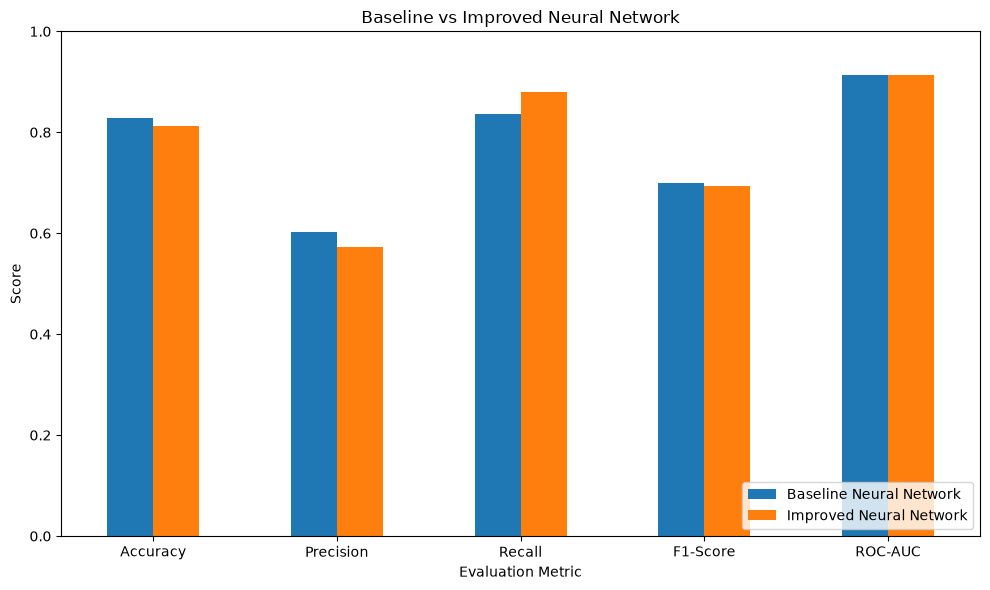

In [31]:
# Plot baseline vs improved neural network

nn_comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Improved Neural Network")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "../screenshots/week5_nn_improvement_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The improved neural network achieved a recall of 87.93%, compared with 83.59% for the baseline model. This indicates that the improved architecture was more effective at detecting individuals belonging to the `>50K` class.

However, accuracy decreased from 82.75% to 81.34%, precision decreased from 60.23% to 57.35%, and F1-score decreased from 70.01% to 69.42%. ROC-AUC remained unchanged at 91.35%.

Therefore, the additional architecture complexity did not produce an overall improvement in predictive performance. The baseline neural network is selected as the final model because it provides a better balance between precision, recall, accuracy, and F1-score.

The improved model would be preferable only when higher recall for the minority class is the primary objective.

## 18. Neural Network Architecture

The final baseline neural network uses a relatively compact architecture because the Adult Income dataset is tabular rather than image- or sequence-based.

The network consists of an input layer, two fully connected hidden layers, dropout layers for regularization, and a sigmoid output neuron for binary classification.

Architecture:

Input Features
→ Dense(64, ReLU)
→ Dropout(0.30)
→ Dense(32, ReLU)
→ Dropout(0.20)
→ Dense(1, Sigmoid)

The ReLU activation functions allow the hidden layers to learn non-linear relationships between the input features. Dropout reduces overfitting by randomly deactivating a proportion of neurons during training. The final sigmoid neuron produces a probability between 0 and 1 for the `>50K` class.

In [32]:
# Display the final baseline neural network architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,269 (106.52 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,180 (71.02 KB)

In [37]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="../screenshots/week5_neural_network_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True
)

print("Architecture diagram created successfully.")

You must install pydot (`pip install pydot`) for `plot_model` to work.
Architecture diagram created successfully.


## 19. Final Model Selection

Two neural-network architectures were evaluated during the experiment.

The baseline neural network achieved:

- Accuracy: 82.75%
- Precision: 60.23%
- Recall: 83.59%
- F1-score: 70.01%
- ROC-AUC: 91.35%

The improved neural network achieved:

- Accuracy: 81.34%
- Precision: 57.35%
- Recall: 87.93%
- F1-score: 69.42%
- ROC-AUC: 91.35%

Although the improved architecture produced higher recall, the baseline model achieved better accuracy, precision, and F1-score while maintaining the same ROC-AUC.

Therefore, the baseline neural network is selected as the final model because it provides the better overall balance between detecting the minority class and maintaining predictive reliability.

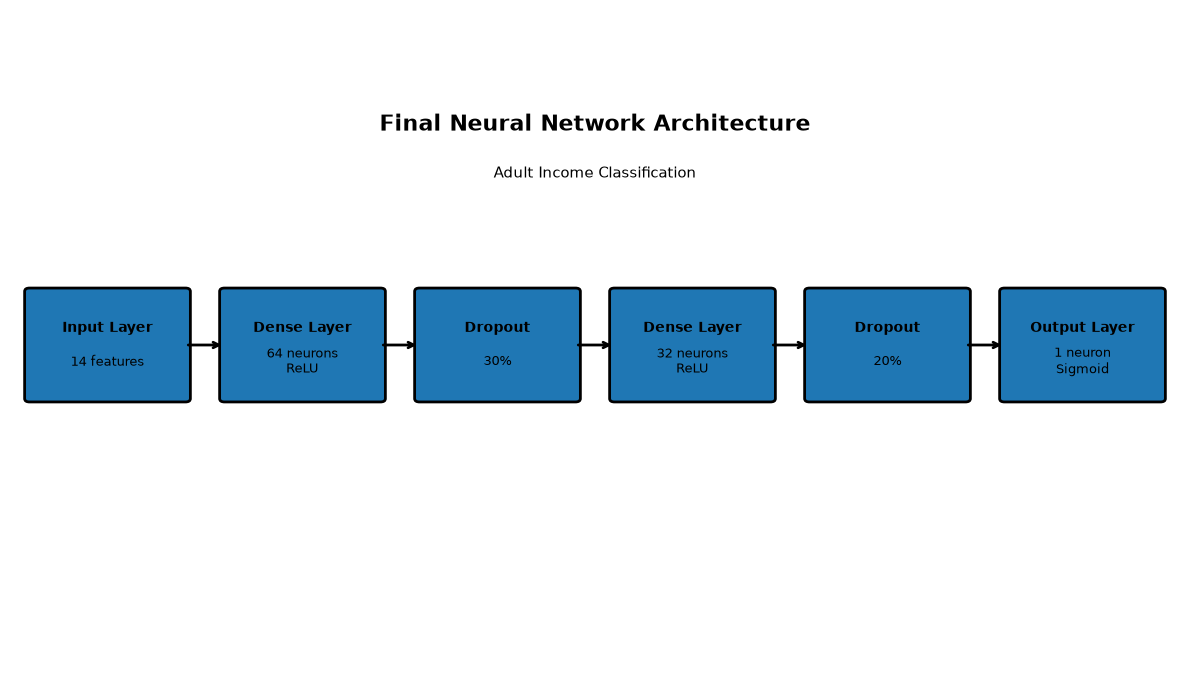

Architecture diagram created successfully.


In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis("off")

# Layer information
layers = [
    ("Input Layer", "14 features", 1),
    ("Dense Layer", "64 neurons\nReLU", 3),
    ("Dropout", "30%", 5),
    ("Dense Layer", "32 neurons\nReLU", 7),
    ("Dropout", "20%", 9),
    ("Output Layer", "1 neuron\nSigmoid", 11)
]

y = 5

# Draw boxes
for title, details, x in layers:
    box = FancyBboxPatch(
        (x - 0.8, y - 0.8),
        1.6,
        1.6,
        boxstyle="round,pad=0.05",
        linewidth=2
    )

    ax.add_patch(box)

    ax.text(
        x,
        y + 0.25,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        x,
        y - 0.25,
        details,
        ha="center",
        va="center",
        fontsize=9
    )

# Draw arrows
for i in range(len(layers) - 1):
    x1 = layers[i][2] + 0.8
    x2 = layers[i + 1][2] - 0.8

    ax.annotate(
        "",
        xy=(x2, y),
        xytext=(x1, y),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

# Title
ax.text(
    6,
    8.2,
    "Final Neural Network Architecture",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

# Subtitle
ax.text(
    6,
    7.5,
    "Adult Income Classification",
    ha="center",
    fontsize=11
)

plt.tight_layout()

# Save diagram
plt.savefig(
    "../screenshots/week5_neural_network_architecture.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Architecture diagram created successfully.")


## 20. Challenges and Solutions

Several challenges were encountered while applying deep learning to the Adult Income dataset.

### 1. Class Imbalance

The dataset contains 24,698 observations in the `<=50K` class and 7,839 observations in the `>50K` class. This imbalance can cause a model to favor the majority class.

**Solution:** Class weights were calculated from the training data and supplied during model training. This increased the importance of the minority `>50K` class.

### 2. Overfitting

A neural network can learn patterns specific to the training data instead of generalizing to unseen observations.

**Solution:** Dropout layers were included in the architecture, and early stopping with restoration of the best validation weights was used during training.

### 3. CPU-Based Training

The model was trained using a CPU environment rather than a dedicated GPU. Although the dataset is relatively small for deep learning, CPU-based training can still increase training time.

**Solution:** A compact fully connected architecture was used instead of a very large network. The use of a maximum of 30 epochs and early stopping also prevented unnecessary training.

### 4. Model Complexity

Increasing the network size does not necessarily improve performance on structured tabular data.

**Solution:** An improved architecture with 128 and 64 neurons was tested. Although it increased minority-class recall, it reduced accuracy, precision, and F1-score. Therefore, the simpler baseline architecture was selected as the final model.

## 21. Key Insights

The deep-learning experiment produced several important findings.

1. The baseline neural network achieved an accuracy of 82.75% and a ROC-AUC of 91.35% on the unseen test set.

2. The model achieved 83.59% recall for the `>50K` class, demonstrating that class weighting helped the network identify a large proportion of higher-income individuals.

3. The confusion matrix showed 983 correctly identified `>50K` individuals and 193 `>50K` individuals incorrectly classified as `<=50K`.

4. The model made 842 incorrect predictions out of 4,881 test observations, corresponding to an error rate of 17.25%.

5. Error analysis showed that incorrectly classified observations had higher average age and working hours than correctly classified observations.

6. The improved architecture increased recall to 87.93%, but its accuracy decreased to 81.34% and F1-score decreased to 69.42%.

7. The Random Forest from Week 4 achieved higher overall accuracy and ROC-AUC, showing that deep learning does not automatically outperform traditional machine-learning methods on tabular data.

8. The experiment demonstrates that model selection should depend on the objective. If identifying as many `>50K` individuals as possible is the priority, the improved model's higher recall may be useful. For a more balanced performance profile, the baseline neural network is preferable.

## 22. Limitations

Although the neural network achieved good predictive performance, several limitations remain.

- The model was trained on a relatively small tabular dataset, so a deep neural network may not provide a major advantage over tree-based machine-learning models.
- The model was trained using CPU resources, which limits the practicality of experimenting with larger and deeper architectures.
- Class weighting improved minority-class recall but reduced precision because more observations were classified as `>50K`.
- The neural network provides less direct interpretability than the feature-importance analysis available from tree-based models.
- The Adult Income dataset represents a specific historical population and may not generalize directly to modern populations or different geographical settings.

## 23. Future Improvements

The model could be improved in several ways:

1. Hyperparameter tuning could be performed for learning rate, batch size, dropout rate, and network size.
2. Different classification thresholds could be tested to find a better precision-recall trade-off.
3. More advanced techniques such as focal loss could be investigated for handling class imbalance.
4. Explainability methods such as SHAP could be applied to better understand individual predictions.
5. The neural network could be compared with specialized tabular deep-learning architectures.
6. Cross-validation could be used to obtain a more robust estimate of neural-network performance.

## 24. Conclusion

This week applied deep learning to the Adult Income classification problem using a fully connected neural network.

The final baseline neural network achieved 82.75% accuracy, 60.23% precision, 83.59% recall, 70.01% F1-score, and a ROC-AUC of 91.35% on the unseen test set.

Class weighting was particularly useful for addressing the imbalance between the `<=50K` and `>50K` income classes. The model successfully identified 983 of the 1,176 higher-income individuals in the test set.

An improved architecture using larger hidden layers and batch normalization was also tested. It increased recall to 87.93%, but accuracy, precision, and F1-score decreased. This demonstrated that increasing model complexity does not necessarily improve overall performance.

When compared with the Week 4 traditional machine-learning models, the neural network did not outperform Random Forest on every metric. Random Forest achieved higher accuracy and ROC-AUC, while the neural network provided stronger minority-class recall.

Overall, the experiment demonstrates that deep learning can perform well on tabular classification problems, but model selection should depend on the specific objective and the trade-offs between accuracy, precision, recall, F1-score, interpretability, and computational requirements.